# SV hyperparameter optimization

The sensitivity or power of spatial variability (SV) tests are determined by **spatial kernel spectrum**. Roughly speaking, kernel spectrum describes what physical frequency (or spatial scale) the test should prioritize, at the expense of other frequencies. In this tutorial, we will explore how SPLISOSM's hyperparameters affect the kernel spectrum, and how that in turn affects SV test results.

This notebook uses the same data and preprocessing steps as [Visium HD FFPE (probe) Part I](visiumhd_ffpe.ipynb). Here, we compare the spatial variability (SV) test results of `SplisosmFFT` and `SplisosmNP` on identical data to illustrate how their distinct kernel hyperparameters influence the outcomes.

Estimated runtime: ~5 min.

## Preliminary notes

SPLISOSM models the spatial prior using a conditional autoregressive (CAR) kernel, defined as $K = (I - \rho \tilde{W})^{-1}$, where $\tilde{W}$ is the sparse adjacency matrix of a spatial $k$-nearest neighbor (k-NN) graph. This kernel relies on two key hyperparameters:

- `k_neighbors` (for NP) / `neighbor_degree` (for FFT): Defines the number of mutual neighbors connected to each spot in the CAR graph. On a regular FFT grid, setting `neighbor_degree=1` corresponds to a 1-hop neighborhood, equivalent to `k_neighbors=4`.
- `rho` ($\rho$): The spatial autocorrelation parameter governing the strength of spatial smoothing.

Prior to `v1.2.0`, SPLISOSM defaulted to a low-rank approximation to scale SV tests for larger datasets ($n > 5,000$), an approach utilized in the original [SPLISOSM paper](https://www.nature.com/articles/s41587-025-02965-6). We have since deprecated this in favor of a full-rank test, which has been reimplemented using a highly efficient [cumulant estimation procedure](../methods.rst). The old low-rank behavior is still accessible via `null_configs={"approx_rank": k}` for diagnostic purposes. It concentrates detection power exclusively on the top-$k$ lower spatial frequencies. In contrast, the full rank test provides a more flexible approach without losing power in other regions. We will demonstrate how to achieve a comparable effect by fine-tuning `rho`. 

**Note: This is not a guide on optimizing hyperparameters to maximize statistical power**. As detailed in our recent preprint [Su et al. arXiv:2602.02825](https://arxiv.org/html/2602.02825v1), there is no universally optimal kernel for spatial pattern detection; enhancing power at one spatial scale inherently diminishes it at another. In the strict sense, tuning hyperparameters on a given dataset constitutes a form of ["p-hacking"](https://en.wikipedia.org/wiki/Data_dredging) and should be avoided except when explicitly justified. The relative gene ranking is more robust to hyperparameter changes than the absolute p-values.

## Imports

In [1]:
from __future__ import annotations

import time
from itertools import combinations
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

import spatialdata as sd

from splisosm import SplisosmFFT, SplisosmNP
from splisosm.io import load_visiumhd_probe

In [2]:
warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (6, 4)

## Configure paths and core parameters

In [3]:
# Required: Space Ranger `outs` directory for Visium HD FFPE
visium_hd_outs = Path("/path/to/visium_hd_ffpe/outs")

# Optional cache path for faster reruns
sdata_zarr = visium_hd_outs / "sdata_probe.filtered.zarr"

# Only 16 um bins are needed for this hyperparameter benchmark
bin_sizes = [16]

# Dataset and table identifiers
# 10x Visium HD FFPE examples often use this dataset prefix for shapes.
dataset_id = "Visium_HD_Mouse_Brain"
test_table = "square_016um"
test_bins_element = f"{dataset_id}_square_016um"

# Probe annotation column names
group_iso_by = "gene_ids"
gene_names = "gene_name"

# A more stringent filter for demonstration purposes. Adjust as needed.
min_counts = 100
min_bin_pct = 0.05
filter_single_iso_genes = True

# Test settings
fdr_threshold = 0.01
n_jobs = -1

In [4]:
# local path
visium_hd_outs = Path("/Users/jysumac/Projects/SPLISOSM_paper/data/visiumhd_ffpe_mouse_cbs/")
sdata_zarr = visium_hd_outs / "sdata_probe.filtered.zarr"

## Load data

If the cached `SpatialData` object is available, load it directly. Otherwise, build it from Space Ranger outputs with `load_visiumhd_probe`.

In [5]:
%%time
if sdata_zarr.exists():
    print("Loading cached SpatialData...")
    sdata = sd.read_zarr(sdata_zarr)
else:
    print("Building probe-level SpatialData from Space Ranger outputs...")
    sdata = load_visiumhd_probe(
        path=visium_hd_outs,
        bin_sizes=bin_sizes,
        filtered_counts_file=True,
        load_all_images=False,
        var_names_make_unique=True,
        counts_layer_name="counts",
    )
    # Optional: cache for future runs
    # sdata.write(sdata_zarr)

sdata

Loading cached SpatialData...
CPU times: user 7.88 s, sys: 1.7 s, total: 9.59 s
Wall time: 5.91 s


SpatialData object, with associated Zarr store: /Users/jysumac/Projects/SPLISOSM_paper/data/visiumhd_ffpe_mouse_cbs/sdata_probe.filtered.zarr
├── Images
│     ├── 'Visium_HD_Mouse_Brain_full_image': DataTree[cyx] (3, 23947, 18872), (3, 11973, 9436), (3, 5986, 4718), (3, 2993, 2359), (3, 1496, 1179)
│     ├── 'Visium_HD_Mouse_Brain_hires_image': DataArray[cyx] (3, 6000, 4729)
│     └── 'Visium_HD_Mouse_Brain_lowres_image': DataArray[cyx] (3, 600, 473)
├── Shapes
│     ├── 'Visium_HD_Mouse_Brain_cell_segmentations': GeoDataFrame shape: (40222, 2) (2D shapes)
│     ├── 'Visium_HD_Mouse_Brain_square_002um': GeoDataFrame shape: (6296688, 1) (2D shapes)
│     ├── 'Visium_HD_Mouse_Brain_square_008um': GeoDataFrame shape: (393543, 1) (2D shapes)
│     └── 'Visium_HD_Mouse_Brain_square_016um': GeoDataFrame shape: (98917, 1) (2D shapes)
└── Tables
      ├── 'cell_segmentations': AnnData (40222, 55538)
      ├── 'square_002um': AnnData (6296688, 55538)
      ├── 'square_008um': AnnData (393543, 5

### Inspect and validate input spatial data

The following setup configurations will be shared across all subsequent analyses.

In [6]:
%%time
setup_params = {
    "sdata": sdata,
    "bins": test_bins_element,
    "table_name": test_table,
    "col_key": "array_col",
    "row_key": "array_row",
    "layer": "counts",
    "group_iso_by": group_iso_by,
    "gene_names": gene_names,
    "min_counts": min_counts,
    "min_bin_pct": min_bin_pct,
    "filter_single_iso_genes": filter_single_iso_genes,
}

try:
    model = SplisosmFFT(neighbor_degree=1, rho=0.99)
    model.setup_data(**setup_params)
    print(model)
except Exception as e:
    print(f"Error during setup: {e}")

=== SplisosmFFT
- Number of genes: 1065
- Number of spots: 98917
- Number of spots after rasterization: 124344
- Number of covariates: 0
- Average isoforms per gene: 2.6
=== Model configurations
- Neighborhood degree: 1
- Spatial autocorrelation rho: 0.99
=== Test results
- Spatial variability: N/A
- Differential usage: N/A
CPU times: user 4.9 s, sys: 337 ms, total: 5.24 s
Wall time: 5.38 s


## Hyperparameters and SV test power

### Kernel spectral analysis

Before we dive into the spatial variability (SV) test results, let's take a moment to understand a key concept: the **kernel spectrum**. If you need a quick refresher on SPLISOSM's exact test statistic, feel free to check out the [Statistical Methods documentation](../methods.rst).

Think of the kernel spectrum as a weighting system that tells the test which spatial patterns to prioritize. A larger eigenvalue means its corresponding eigenvector (the spatial pattern) carries more weight in the test. On a regular grid, the eigenvectors of our conditional autoregressive (CAR) kernel are essentially Fourier modes, each with a specific 2D spatial frequency.

To see this in action, we can visualize the kernel's [radial power spectral density (PSD)](https://en.wikipedia.org/wiki/Spectral_density), along with two representative eigenpatterns.

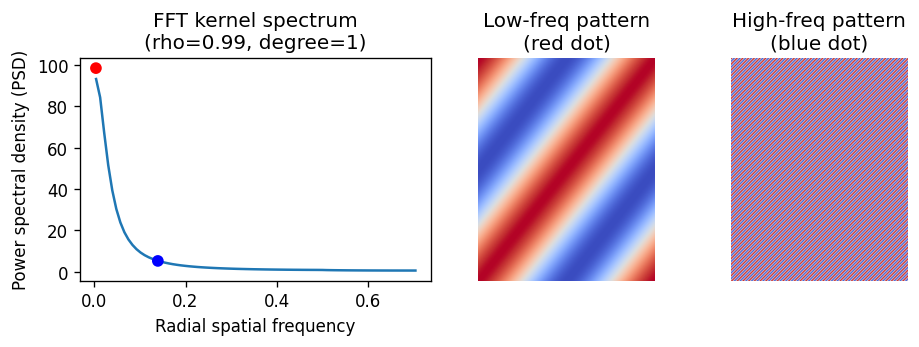

CPU times: user 80.9 ms, sys: 11.6 ms, total: 92.5 ms
Wall time: 95 ms


In [7]:
%%time
def plot_fft_eigen_patterns(model, bins=80):
    """Plot PSD plus representative low- and high-frequency FFT eigenpatterns."""
    k = model.sp_kernel
    freq_bins, psd_1d = k.power_spectral_density_1d(bins=bins)

    fy = np.fft.fftfreq(k.ny, d=k.dy)
    fx = np.fft.fftfreq(k.nx, d=k.dx)
    fy_grid, fx_grid = np.meshgrid(fy, fx, indexing="ij")
    radial_freq = np.sqrt(fy_grid**2 + fx_grid**2)

    # Select one low-freq and one high-freq mode for visualization
    low_idx = (1, 1)
    high_idx = (k.ny // 10, k.nx // 10)
    yy = np.arange(k.ny)[:, None]
    xx = np.arange(k.nx)[None, :]

    def eigenpattern(idx):
        iy, ix = idx
        z = np.cos(2 * np.pi * (iy * yy / k.ny + ix * xx / k.nx))
        z -= z.mean()
        z /= np.sqrt(np.mean(z**2))
        return z

    mode_info = pd.DataFrame(
        [
            {
                "pattern": "low",
                "freq_y": fy[low_idx[0]],
                "freq_x": fx[low_idx[1]],
                "radial_freq": radial_freq[low_idx],
                "kernel_eigenvalue": k._spectrum_2d[low_idx],
            },
            {
                "pattern": "high",
                "freq_y": fy[high_idx[0]],
                "freq_x": fx[high_idx[1]],
                "radial_freq": radial_freq[high_idx],
                "kernel_eigenvalue": k._spectrum_2d[high_idx],
            },
        ]
    )

    fig, axes = plt.subplots(1, 3, figsize=(8, 3), width_ratios=[1.5, 1, 1])

    axes[0].plot(freq_bins, psd_1d)
    axes[0].scatter(
        mode_info["radial_freq"],
        mode_info["kernel_eigenvalue"],
        color=["red", "blue"],
        zorder=3,
    )
    axes[0].set_xlabel("Radial spatial frequency")
    axes[0].set_ylabel("Power spectral density (PSD)")
    axes[0].set_title("FFT kernel spectrum\n(rho=0.99, degree=1)")

    axes[1].imshow(eigenpattern(low_idx), cmap="coolwarm")
    axes[1].set_title("Low-freq pattern\n(red dot)")
    axes[1].axis("off")

    axes[2].imshow(eigenpattern(high_idx), cmap="coolwarm")
    axes[2].set_title("High-freq pattern\n(blue dot)")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

plot_fft_eigen_patterns(model)


The low-frequency one can be detected with higher power because of its much larger eigenvalue (the red dot). Note that normalizing the kernel spectrum does not change SV test results. For convenience, we will normalize it to sum to one when comparing across different hyperparameter settings.

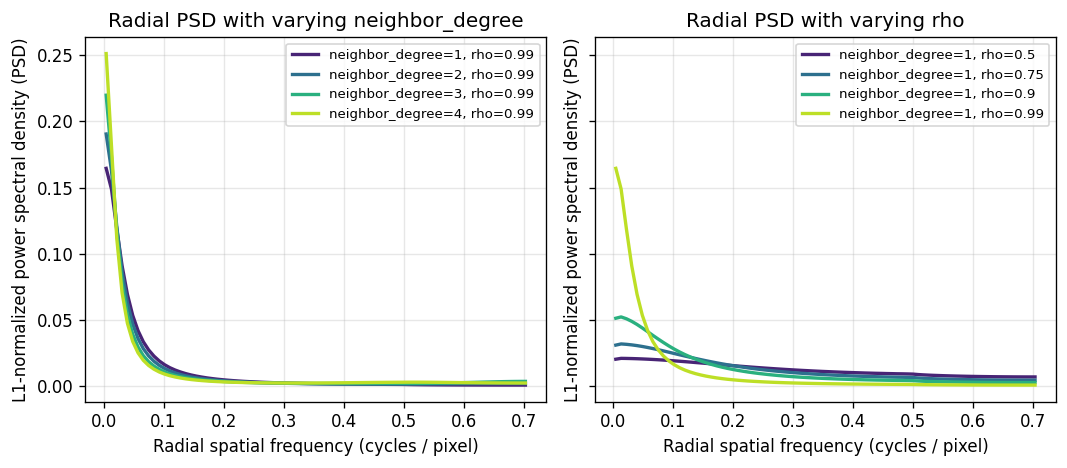

CPU times: user 22.9 s, sys: 1.12 s, total: 24 s
Wall time: 24 s


In [8]:
%%time
def extract_l1_normalized_psd(model, bins=80):
    """Return radial PSD with L1 normalization for comparison across kernels."""
    freq_bins, psd = model.sp_kernel.power_spectral_density_1d(bins=bins)
    # scale eigenvalues to sum-one
    denom = float(np.sum(np.abs(psd)))
    if denom <= 0.0:
        raise ValueError("Power spectral density has zero total magnitude.")
    return freq_bins, psd / denom

def plot_psd_family(configs, title, ax, bins=80):
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(configs)))

    for cfg, color in zip(configs, colors):
        m = SplisosmFFT(**cfg)
        m.setup_data(**setup_params)
        freq_bins, psd_l1 = extract_l1_normalized_psd(m, bins=bins)
        label = ", ".join([f"{key}={value}" for key, value in cfg.items()])
        ax.plot(freq_bins, psd_l1, color=color, linewidth=2.0, label=label)

    ax.set_xlabel("Radial spatial frequency (cycles / pixel)")
    ax.set_ylabel("L1-normalized power spectral density (PSD)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)


neighbor_configs = [
    {"neighbor_degree": 1, "rho": 0.99},
    {"neighbor_degree": 2, "rho": 0.99},
    {"neighbor_degree": 3, "rho": 0.99},
    {"neighbor_degree": 4, "rho": 0.99},
]

rho_configs = [
    {"neighbor_degree": 1, "rho": 0.50},
    {"neighbor_degree": 1, "rho": 0.75},
    {"neighbor_degree": 1, "rho": 0.90},
    {"neighbor_degree": 1, "rho": 0.99},
]

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
plot_psd_family(
    neighbor_configs,
    title="Radial PSD with varying neighbor_degree",
    ax=axes[0],
    bins=80,
)
plot_psd_family(
    rho_configs,
    title="Radial PSD with varying rho",
    ax=axes[1],
    bins=80,
)
plt.tight_layout()
plt.show()

As shown above, increasing `rho` or `neighbor_degree` shifts the test's focus toward lower frequencies, which represent broad, smoothly varying global patterns. Between the two, `rho` is actually the more effective parameter for dialing in on those low-frequency signals.

### HP effects on SV test results

Now let's see how these hyperparameter-induced shifts in kernel spectrum affect SV test results.

In [9]:
%%time
configs = [
    {"neighbor_degree": 1, "rho": 0.99},
    {"neighbor_degree": 2, "rho": 0.99},
    {"neighbor_degree": 1, "rho": 0.90},
]

cfg_results = []
for cfg in configs:
    m = SplisosmFFT(neighbor_degree=cfg["neighbor_degree"], rho=cfg["rho"])
    m.setup_data(**setup_params)
    m.test_spatial_variability(
        method='hsic-ir',
        ratio_transformation='none',
        n_jobs=-1,
        print_progress=True,
    )
    res = m.get_formatted_test_results("sv")[["gene", "pvalue", "pvalue_adj"]].copy()
    tag = f"k{cfg['neighbor_degree']}_rho{cfg['rho']}"
    res = res.rename(columns={"pvalue": f"p_{tag}", "pvalue_adj": f"padj_{tag}"})
    cfg_results.append(res)

SV [hsic-ir]: 100%|██████████| 88/88 [00:03<00:00, 26.80it/s]


CPU times: user 50.4 s, sys: 10.1 s, total: 1min
Wall time: 21.7 s


While the overall gene ranking remains consistent across different hyperparameter settings, due to its more pronounced effect on the kernel spectrum, `rho` has a larger impact on SV test results than `neighbor_degree`.

In [10]:
merged = cfg_results[0]
for res in cfg_results[1:]:
    merged = merged.merge(res, on="gene", how="inner")

p_cols = [c for c in merged.columns if c.startswith("p_")]
print("Spearman correlation across hyperparameter settings:")
display(merged[p_cols].corr(method="spearman"))

Spearman correlation across hyperparameter settings:


,p_k1_rho0.99,p_k2_rho0.99,p_k1_rho0.9
p_k1_rho0.99,1.000000,0.992540,0.818167
p_k2_rho0.99,0.992540,1.000000,0.757237
p_k1_rho0.9,0.818167,0.757237,1.000000


 For this mouse brain dataset, most spatial patterns are low-frequency, so decreasing `rho` reduces statistical power.

In [11]:
print("SVP calling (FDR < 0.01):")
for cfg in configs:
    tag = f"k{cfg['neighbor_degree']}_rho{cfg['rho']}"
    svp_count = (merged[f"padj_{tag}"] < fdr_threshold).sum()
    print(f"  {tag}: {svp_count} SVP genes")

SVP calling (FDR < 0.01):
  k1_rho0.99: 113 SVP genes
  k2_rho0.99: 127 SVP genes
  k1_rho0.9: 12 SVP genes


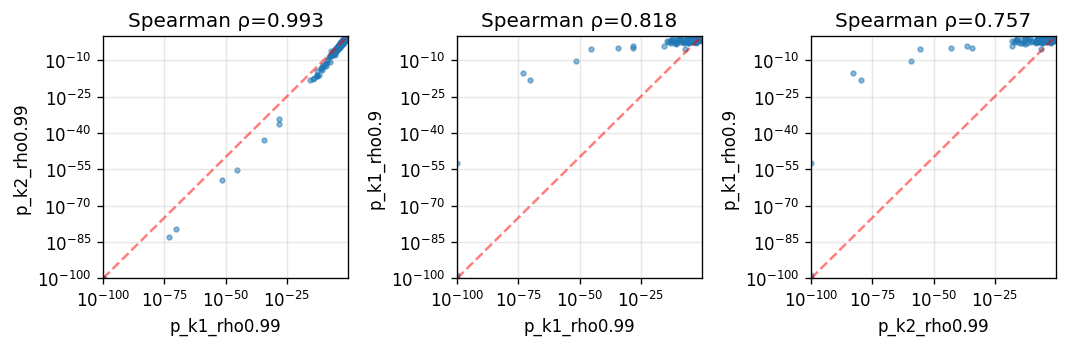

In [12]:
pairs = list(combinations(p_cols, 2))
if pairs:
    fig, axes = plt.subplots(1, len(pairs), figsize=(3 * len(pairs), 3), squeeze=False)
    axes = axes.ravel()

    for ax, (x_col, y_col) in zip(axes, pairs):
        x = merged[x_col].to_numpy()
        y = merged[y_col].to_numpy()
        corr, pval = spearmanr(x, y)

        ax.scatter(x + 1e-100, y + 1e-100, s=8, alpha=0.5)
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
        ax.set_title(f"Spearman ρ={corr:.3f}")
        ax.grid(True, alpha=0.3)

        low = 1e-100
        high = max(np.max(x), np.max(y))
        ax.plot([low, high], [low, high], "r--", alpha=0.5, linewidth=1.5)
        ax.set_xlim(low, high)
        ax.set_ylim(low, high)

    plt.tight_layout()
    plt.show()

## Full-rank and low-rank `SplisosmNP` comparison

In prior versions, SPLISOSM implemented a low-rank approximation default for larger datasets ($n > 5,000$) with rank $k = \lceil{4 * \sqrt{n}}\rceil$. In terms of kernel spectrum, this approach concentrates all detection power exclusively on the top-$k$ lower spatial frequencies. On the computational side, this requires a sparse eigen-decomposition of complexity $\mathcal(O)(n^2 k)$, which is still expensive when $n$ or $k$ is large.

Since `v1.2.0`, we have reimplemented the full-rank test using a highly efficient Hutchinson trace-based cumulant estimation procedure. It has a complexity of $\mathcal(O)(m \cdot n\log n)$, where $m=60$ (`null_configs={"n_probes": 60}` by default) is the number of random vectors used for estimation. Smaller $m$ values make the test even faster but also noisier. 

In this section, we will compare the new full-rank default with the old low-rank approximation, and see how we can achieve a similar global-focused effect by fine-tuning `rho`.

In [13]:
def setup_np_model(rho: float) -> SplisosmNP:
    model = SplisosmNP(
        k_neighbors=4,
        rho=rho,
        standardize_cov=False,
    )
    model.setup_data(
        adata=sdata.tables[test_table],
        spatial_key="spatial",
        layer="counts",
        group_iso_by=group_iso_by,
        gene_names=gene_names,
        min_counts=min_counts,
        min_bin_pct=min_bin_pct,
        filter_single_iso_genes=filter_single_iso_genes,
        min_component_size=10,
    )
    return model


def run_np_sv(model: SplisosmNP, label: str, null_configs: dict) -> tuple[pd.DataFrame, float]:
    print(f"Running {label}")
    tic = time.perf_counter()
    model.test_spatial_variability(
        method="hsic-ir",
        ratio_transformation="none",
        null_method="liu",
        null_configs=null_configs,
        chunk_size="auto",
        n_jobs=n_jobs,
        print_progress=True,
    )
    elapsed = time.perf_counter() - tic

    res = model.get_formatted_test_results(
        "sv",
        with_gene_summary=True,
    ).sort_values("pvalue_adj")

    print(f"{label} finished in {elapsed / 60:.1f} min")
    return res, elapsed


def summarize_np_results(results: dict[str, pd.DataFrame], runtimes: dict[str, float]) -> pd.DataFrame:
    return pd.DataFrame(
        [
            {
                "method": label,
                "runtime_min": runtimes[label] / 60,
                f"SVP (FDR < {fdr_threshold:g})": int((res["pvalue_adj"] < fdr_threshold).sum()),
                "tested_genes": res.shape[0],
            }
            for label, res in results.items()
        ]
    )

### Low-rank approximation prefers low frequencies

The smaller the `approx_rank`, the more the test focuses on low frequencies. Since most biologically relevant spatial patterns are smooth, the legacy low-rank approach may appear to have higher statistical power (more SVP calls) at first glance. However, it is important to note that this comes at the cost of completely losing power for any patterns outside the top-$k$ frequencies. 

In [14]:
%%time
# Run full-rank and low-rank NP tests with the same rho to compare their results and runtimes.
model_np_full = setup_np_model(rho=0.99)
n_spots_np = model_np_full.filtered_adata.n_obs
legacy_approx_rank = int(np.ceil(4 * np.sqrt(n_spots_np)))
cap_rank = min(legacy_approx_rank, 500)  # Cap rank to save time if many spots
print(f"NP observed spots after filtering: {n_spots_np:,}")
print(f"Legacy default approx_rank: {legacy_approx_rank:,}")
print(f"Using cap_rank={cap_rank} for low-rank test to save time.")

np_results = {}
np_runtimes = {}

np_results["NP full-rank rho=0.99"], np_runtimes["NP full-rank rho=0.99"] = run_np_sv(
    model_np_full,
    label="NP full-rank rho=0.99",
    null_configs={"n_probes": 60, "rng_seed": 0},
)

model_np_lowrank = setup_np_model(rho=0.99)
np_results["NP low-rank rho=0.99"], np_runtimes["NP low-rank rho=0.99"] = run_np_sv(
    model_np_lowrank,
    label="NP low-rank rho=0.99",
    null_configs={"approx_rank": cap_rank, "rng_seed": 0},
)

np_same_rho_summary = summarize_np_results(np_results, np_runtimes)
display(np_same_rho_summary)

np_same_rho = (
    np_results["NP full-rank rho=0.99"][["gene", "pvalue", "pvalue_adj"]]
    .rename(columns={"pvalue": "p_full", "pvalue_adj": "padj_full"})
    .merge(
        np_results["NP low-rank rho=0.99"][["gene", "pvalue", "pvalue_adj"]]
        .rename(columns={"pvalue": "p_lowrank", "pvalue_adj": "padj_lowrank"}),
        on="gene",
        how="inner",
    )
)

rho_full_lowrank, _ = spearmanr(np_same_rho["p_full"], np_same_rho["p_lowrank"])
print(f"Full-rank vs low-rank p-value Spearman rho: {rho_full_lowrank:.3f}")

NP observed spots after filtering: 98,917
Legacy default approx_rank: 1,259
Using cap_rank=500 for low-rank test to save time.
Running NP full-rank rho=0.99


SV [hsic-ir]: 100%|██████████| 88/88 [00:02<00:00, 29.88it/s]


NP full-rank rho=0.99 finished in 0.1 min
Running NP low-rank rho=0.99


SV [hsic-ir]: 100%|██████████| 88/88 [00:09<00:00,  9.12it/s]


NP low-rank rho=0.99 finished in 1.5 min


,method,runtime_min,SVP (FDR < 0.01),tested_genes
0,NP full-rank rho=0.99,0.085057,72,1065
1,NP low-rank rho=0.99,1.450614,88,1065


Full-rank vs low-rank p-value Spearman rho: 0.867
CPU times: user 3min 7s, sys: 20.3 s, total: 3min 27s
Wall time: 1min 37s


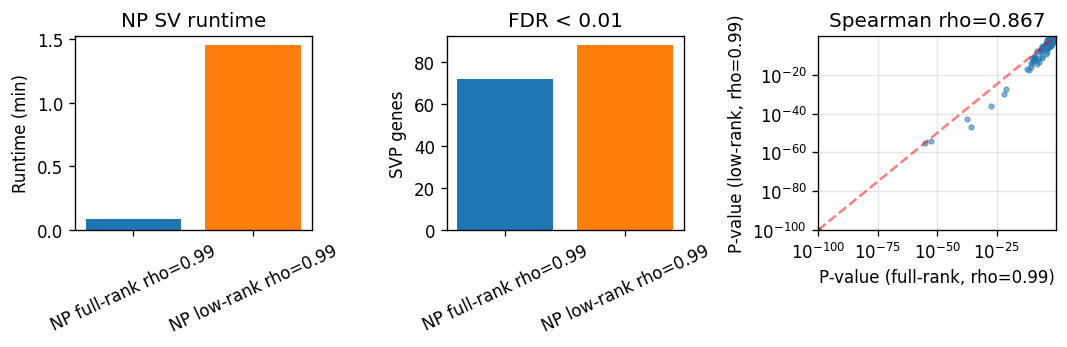

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

axes[0].bar(
    np_same_rho_summary["method"],
    np_same_rho_summary["runtime_min"],
    color=["C0", "C1"],
)
axes[0].set_ylabel("Runtime (min)")
axes[0].set_title("NP SV runtime")
axes[0].tick_params(axis="x", rotation=25)

svp_col = f"SVP (FDR < {fdr_threshold:g})"
axes[1].bar(
    np_same_rho_summary["method"],
    np_same_rho_summary[svp_col],
    color=["C0", "C1"],
)
axes[1].set_ylabel("SVP genes")
axes[1].set_title(f"FDR < {fdr_threshold:g}")
axes[1].tick_params(axis="x", rotation=25)

x = np_same_rho["p_full"].to_numpy()
y = np_same_rho["p_lowrank"].to_numpy()

axes[2].scatter(x + 1e-100, y + 1e-100, s=8, alpha=0.5)
axes[2].set_xscale("log")
axes[2].set_yscale("log")
axes[2].set_xlabel("P-value (full-rank, rho=0.99)")
axes[2].set_ylabel("P-value (low-rank, rho=0.99)")
axes[2].set_title(f"Spearman rho={rho_full_lowrank:.3f}")
axes[2].grid(True, alpha=0.3)

low = 1e-100
high = max(np.max(x), np.max(y))
axes[2].plot([low, high], [low, high], "r--", alpha=0.5, linewidth=1.5)
axes[2].set_xlim(low, high)
axes[2].set_ylim(low, high)

plt.tight_layout()
plt.show()


### Global-focused full-rank test via `rho` tuning

When global patterns are intentionally of interest, it is more appropriate to use a global-focused full-rank test by increasing the value of `rho`. This keeps the test ability (albeit reduced) to detect local patterns.

In [16]:
%%time
model_np_smooth = setup_np_model(rho=0.999)
np_results["NP full-rank rho=0.999"], np_runtimes["NP full-rank rho=0.999"] = run_np_sv(
    model_np_smooth,
    label="NP full-rank rho=0.999",
    null_configs={"n_probes": 60, "rng_seed": 0},
)

np_all_summary = summarize_np_results(np_results, np_runtimes)
display(np_all_summary)

Running NP full-rank rho=0.999


SV [hsic-ir]: 100%|██████████| 88/88 [00:02<00:00, 34.98it/s]


NP full-rank rho=0.999 finished in 0.1 min


,method,runtime_min,SVP (FDR < 0.01),tested_genes
0,NP full-rank rho=0.99,0.085057,72,1065
1,NP low-rank rho=0.99,1.450614,88,1065
2,NP full-rank rho=0.999,0.072932,234,1065


CPU times: user 26.3 s, sys: 2.55 s, total: 28.8 s
Wall time: 6.79 s


Despite differences in the number of SVP calls, the overall gene ranking is still largely consistent across different hyperparameter settings, which is reassuring for the robustness of SV test results.

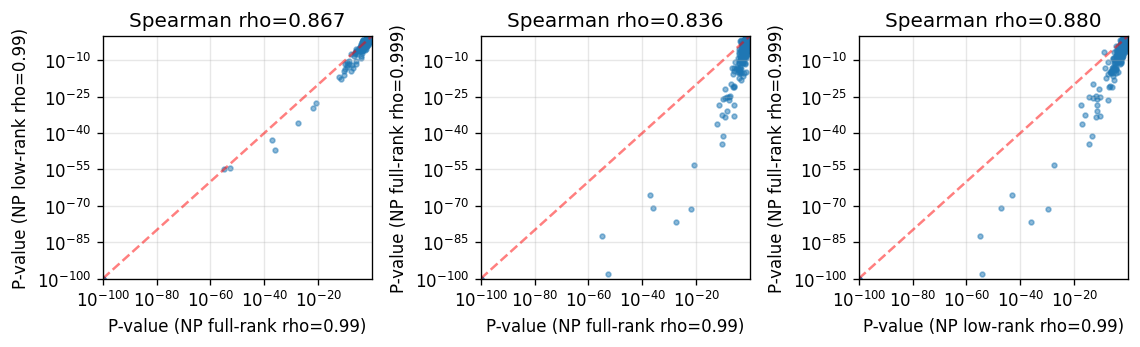

CPU times: user 150 ms, sys: 7.45 ms, total: 158 ms
Wall time: 158 ms


In [17]:
%%time
merged = None
for label, res in np_results.items():
    res_i = res[["gene", "pvalue"]].rename(columns={"pvalue": f"P-value ({label})"})
    merged = res_i if merged is None else merged.merge(res_i, on="gene", how="inner")

p_cols = [col for col in merged.columns if col.startswith("P-value")]
pairs = list(combinations(p_cols, 2))

if pairs:
    fig, axes = plt.subplots(
        1,
        len(pairs),
        figsize=(3.2 * len(pairs), 3),
        squeeze=False,
    )
    axes = axes.ravel()

    for ax, (x_col, y_col) in zip(axes, pairs, strict=False):
        x = merged[x_col].to_numpy()
        y = merged[y_col].to_numpy()
        corr, _ = spearmanr(x, y)

        ax.scatter(x + 1e-100, y + 1e-100, s=8, alpha=0.5)
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
        ax.set_title(f"Spearman rho={corr:.3f}")
        ax.grid(True, alpha=0.3)

        low = 1e-100
        high = max(np.max(x), np.max(y))
        ax.plot([low, high], [low, high], "r--", alpha=0.5, linewidth=1.5)
        ax.set_xlim(low, high)
        ax.set_ylim(low, high)

    plt.tight_layout()
    plt.show()


SV results of the full-rank `SplisosmNP` are also largely consistent with `SplisosmFFT` results of the same hyperparameters.

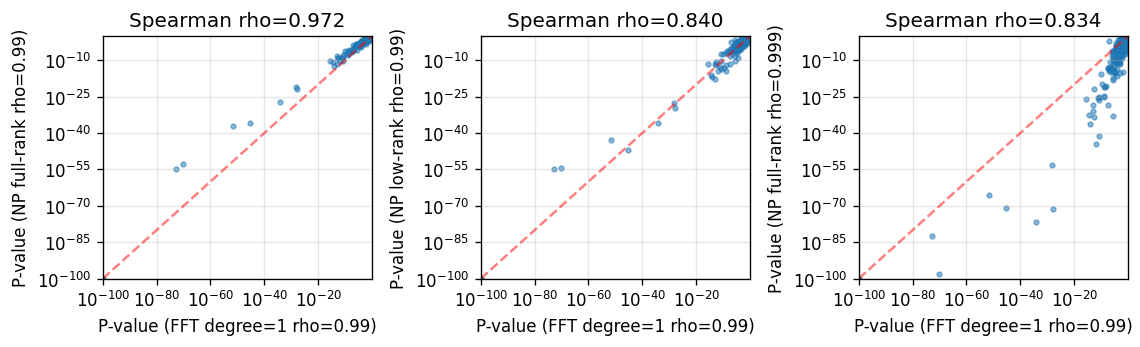

CPU times: user 17.5 s, sys: 3.17 s, total: 20.7 s
Wall time: 7.55 s


In [18]:
%%time
def plot_np_vs_fft_reference(
    np_results: dict[str, pd.DataFrame],
):
    """Plot p-value scatter panels for NP results against the FFT reference."""
    model_fft_ref = SplisosmFFT(neighbor_degree=1, rho=0.99)
    model_fft_ref.setup_data(**setup_params)
    model_fft_ref.test_spatial_variability(
        method='hsic-ir',
        ratio_transformation='none',
        print_progress=False,
    )
    ref = model_fft_ref.get_formatted_test_results("sv")[["gene", "pvalue"]].copy().rename(
        columns={"pvalue": "p_fft_ref"}
    )

    fig, axes = plt.subplots(
        1,
        len(np_results),
        figsize=(3.2 * len(np_results), 3),
        squeeze=False,
    )
    axes = axes.ravel()

    for ax, (label, res) in zip(axes, np_results.items(), strict=False):
        merged = ref.merge(
            res[["gene", "pvalue"]].rename(columns={"pvalue": "p_np"}),
            on="gene",
            how="inner",
        )

        x = merged["p_fft_ref"].to_numpy()
        y = merged["p_np"].to_numpy()
        corr, _ = spearmanr(x, y)

        ax.scatter(x + 1e-100, y + 1e-100, s=8, alpha=0.5)
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("P-value (FFT degree=1 rho=0.99)")
        ax.set_ylabel(f"P-value ({label})")
        ax.set_title(f"Spearman rho={corr:.3f}")
        ax.grid(True, alpha=0.3)

        low = 1e-100
        high = max(np.max(x), np.max(y))
        ax.plot([low, high], [low, high], "r--", alpha=0.5, linewidth=1.5)
        ax.set_xlim(low, high)
        ax.set_ylim(low, high)

    plt.tight_layout()
    plt.show()

plot_np_vs_fft_reference(np_results=np_results)

## Summary and recommendations

**Recommended defaults**

- Use `SplisosmFFT` for regular grids such as Visium HD.
- Use `SplisosmNP` for irregular geometries. The `v1.2.0` default full-rank SV path matches the FFT version on regular grids.

**When tuning spatial scale**

- Increase `rho` when broad tissue-scale patterns are the target.
- Decrease `rho` only when local variation is expected to matter more.
- Prefer `rho=0.999` over rank truncation when the goal is to emphasize smooth global patterns.

**When comparing with old results**

- `null_configs={"approx_rank": k}` is best treated as a legacy or diagnostic option.
- Gene rankings are often more stable than fixed-FDR SVP counts.

## For reproducibility

In [19]:
import sys
from datetime import date
import splisosm

print('Last updated:', date.today())
print('Python:', sys.version.split()[0])
print('splisosm:', getattr(splisosm, '__version__', 'unknown'))

Last updated: 2026-05-03
Python: 3.12.13
splisosm: 1.2.0rc1
